## Financial News Sentiment Analysis

### Libraries

In [1]:
# import libraries
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..'))) # Adding racine path of project to sys.path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import warnings
from src.preprocessing import * # Module created

warnings.filterwarnings('ignore')

### Import data and preprocessing

In [2]:
df = wrangle('../data/raw_analyst_ratings.csv') #Preprocessing function defined in src module
df.info()
df.head()

<class 'pandas.DataFrame'>
DatetimeIndex: 1407327 entries, 2020-06-05 14:30:54+00:00 to 2011-05-12 00:00:00+00:00
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   headline   1407327 non-null  str  
 1   url        1407327 non-null  str  
 2   publisher  1407327 non-null  str  
 3   stock      1407327 non-null  str  
dtypes: str(4)
memory usage: 53.7 MB


,headline,url,publisher,stock
date,,,,
2020-06-05 14:30:54+00:00,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,A
2020-06-03 14:45:20+00:00,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,A
2020-05-26 08:30:07+00:00,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,A
2020-05-22 16:45:06+00:00,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,A
2020-05-22 15:38:59+00:00,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,A


### Exploratory Data Analysis

#### Descriptive statistics

In [4]:
# Headline length
df["headline_length"] = df["headline"].apply(lambda i: len(i))
df.head()

,headline,url,publisher,stock,headline_length
date,,,,,
2020-06-05 14:30:54+00:00,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,A,39
2020-06-03 14:45:20+00:00,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,A,42
2020-05-26 08:30:07+00:00,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,A,29
2020-05-22 16:45:06+00:00,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,A,44
2020-05-22 15:38:59+00:00,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,A,87


In [5]:
df["headline_length"].describe()

count    1.407327e+06
mean     7.312054e+01
std      4.073532e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

In [6]:
# The database possess duplicates on subset columns "headline" and "publisher"
df.duplicated(subset=["headline","publisher"]).sum()

np.int64(555383)

In [7]:
# To access to the real number of articles per publisher, we need to drop duplicates on subset 
# columns "headline" and "publisher"
df_clean = df.drop_duplicates(subset=["headline","publisher"])

In [8]:
stats_publisher = df_clean["publisher"].value_counts()
stats_publisher = stats_publisher.reset_index()
stats_publisher.columns = ["publisher","count"]
top_publishers = stats_publisher.head(10)
top_publishers

,publisher,count
0,Paul Quintaro,210483
1,Benzinga Newsdesk,93272
2,Charles Gross,82143
3,Eddie Staley,53843
4,Hal Lindon,43392
5,Juan Lopez,27714
6,Vick Meyer,24658
7,Benzinga Staff,22644
8,Monica Gerson,21638
9,Benzinga_Newsdesk,18198


Text(0, 0.5, 'Publisher')

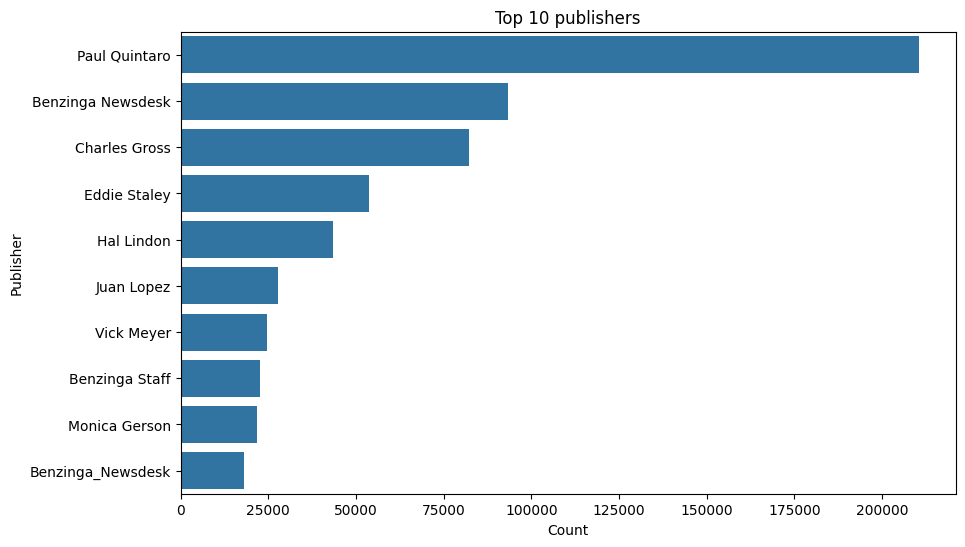

In [9]:
# Graph of the top 10 publishers
plt.figure(figsize=(10,6))
sns.barplot(x="count",y="publisher",data=top_publishers)
plt.title("Top 10 publishers")
plt.xlabel("Count")
plt.ylabel("Publisher")

#### Trend analysis of the publications

##### Day trend analysis

In [ ]:
# We have data that are going from 2009-02-14 till 2020-06-11.